1. Environment setup

▪ Install required packages: pandas, scikit-learn, wfdb, matplotlib, seaborn (optional for
visualization if allowed), numpy.


In [ ]:
%pip install pandas scikit-learn wfdb matplotlib seaborn numpy

In [1]:
import pandas as pd
import numpy as np
import sklearn
import wfdb
import matplotlib
import seaborn as sns

print("All required libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All required libraries imported successfully!


In [2]:
print("Pandas      :", pd.__version__)
print("NumPy       :", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("WFDB        :", wfdb.__version__)
print("Matplotlib  :", matplotlib.__version__)
print("Seaborn     :", sns.__version__)

Pandas      : 3.0.5
NumPy       : 2.5.2
Scikit-learn: 1.9.0
WFDB        : 4.3.1
Matplotlib  : 3.11.1
Seaborn     : 0.13.2


2. Tabular data ingestion (Heart Disease)

▪ Download Cleveland Heart Disease CSV from UCI (or Kaggle mirror).

▪ Inspect schema, handle missing values, map target to binary (0 vs 1+).

▪ Basic exploratory data analysis: distributions, correlations.

▪ Train a baseline classifier (e.g., logistic regression) to predict heart disease presence.

▪ Evaluate with accuracy, ROC AUC, confusion matrix.

In [3]:
# Path to Cleveland Heart Disease dataset
file_path = "heart+disease/processed.cleveland.data"

# Load dataset
df = pd.read_csv(file_path, header=None)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (303, 14)


In [4]:
df.info


<bound method DataFrame.info of        0    1    2      3      4    5    6      7    8    9    10   11   12  \
0    63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   
1    67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   
2    67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   
3    37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   
4    41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   
..    ...  ...  ...    ...    ...  ...  ...    ...  ...  ...  ...  ...  ...   
298  45.0  1.0  1.0  110.0  264.0  0.0  0.0  132.0  0.0  1.2  2.0  0.0  7.0   
299  68.0  1.0  4.0  144.0  193.0  1.0  0.0  141.0  0.0  3.4  2.0  2.0  7.0   
300  57.0  1.0  4.0  130.0  131.0  0.0  0.0  115.0  1.0  1.2  2.0  1.0  7.0   
301  57.0  0.0  2.0  130.0  236.0  0.0  2.0  174.0  0.0  0.0  2.0  1.0  3.0   
302  38.0  1.0  3.0  138.0  175.0  0.0  0.0  173.0  0.0  0.0  1.0    ?  3.0   

     13  
0     0  

In [6]:
# we can see that headers are missing aur dataset is start from 0 to 13 columns. So we will add headers to the dataset.
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df.columns = columns

print(df.head())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  


In [7]:
# to instect the schema of the dataset we can use the info() method which will give us the information about the dataset like number of rows, columns, data types, etc.
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (303, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca              str
thal            str
target        int64
dtype: object


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [11]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


In [9]:
print("Missing value markers:")
print((df == "?").sum())

Missing value markers:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [12]:
df = df.replace("?", np.nan)

In [13]:
print("Missing values after replacement:")
print(df.isnull().sum())

Missing values after replacement:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [14]:
print("Missing value markers:")
print((df == "?").sum())

Missing value markers:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [15]:
df = df.apply(pd.to_numeric)

In [16]:
print(df.dtypes)

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


In [18]:
print("Shape before removing missing values:", df.shape)

df = df.dropna()

print("Shape after removing missing values:", df.shape)

Shape before removing missing values: (303, 14)
Shape after removing missing values: (297, 14)


In [19]:
# missing values have been removed from the dataset.
# now we will map target to binary (0 vs 1+)
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

In [21]:
print(df["target"].value_counts())

target
0    160
1    137
Name: count, dtype: int64


In [22]:
print(df["target"].value_counts(normalize=True) * 100)

target
0    53.872054
1    46.127946
Name: proportion, dtype: float64


In [23]:
# Basic exploratory data analysis: distributions, correlations.
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


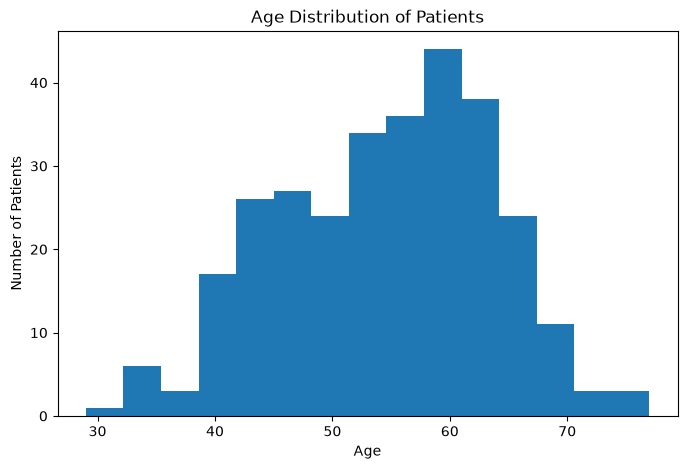

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=15)

plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of Patients")

plt.show()

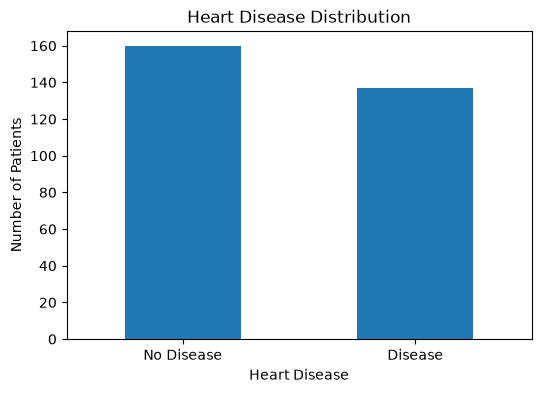

In [26]:
plt.figure(figsize=(6, 4))

df["target"].value_counts().plot(kind="bar")

plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Distribution")
plt.xticks([0, 1], ["No Disease", "Disease"], rotation=0)

plt.show()

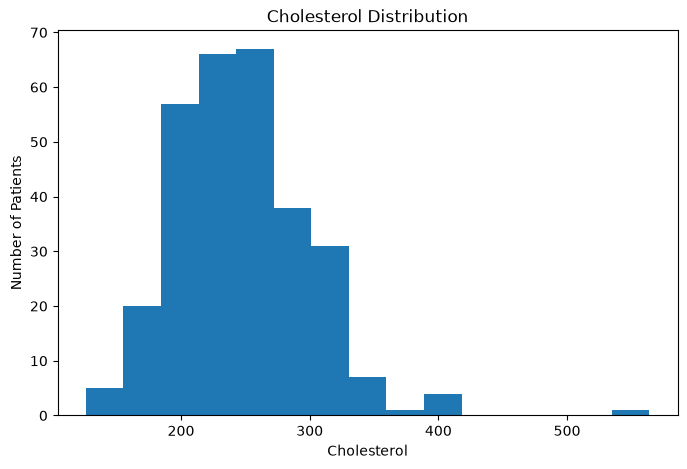

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(df["chol"], bins=15)

plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")
plt.title("Cholesterol Distribution")

plt.show()

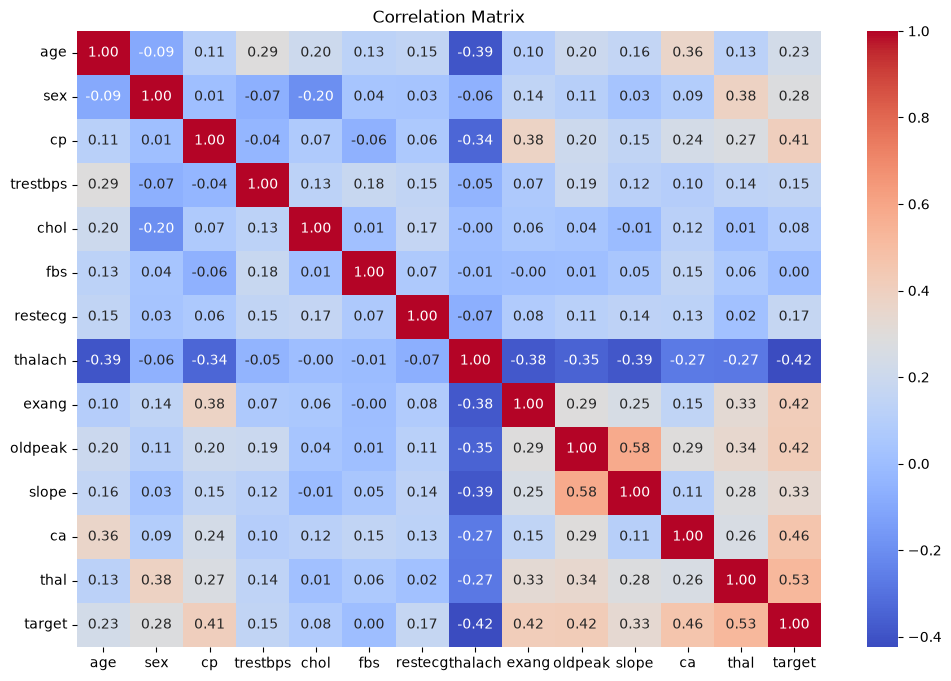

In [28]:
# correlation analysis
correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [29]:
# Train a baseline classifier (e.g., logistic regression) to predict heart disease presence.
X = df.drop("target", axis=1)
y = df["target"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 237
Testing samples: 60


In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


c:\Users\VAIBHAV GUPTA\OneDrive - BENNETT UNIVERSITY\VAIBHAV GUPTA ALL FILES\B.TECH SEM7\CSET343 (AI in Helthcare)\Lab\venvCSET343\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [35]:
# valuate with accuracy, ROC AUC, confusion matrix
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy * 100:.2f}%")


from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC AUC: {roc_auc:.4f}")


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Accuracy: 0.8333333333333334
Accuracy: 83.33%
ROC AUC: 0.9487
Confusion Matrix:
[[28  4]
 [ 6 22]]


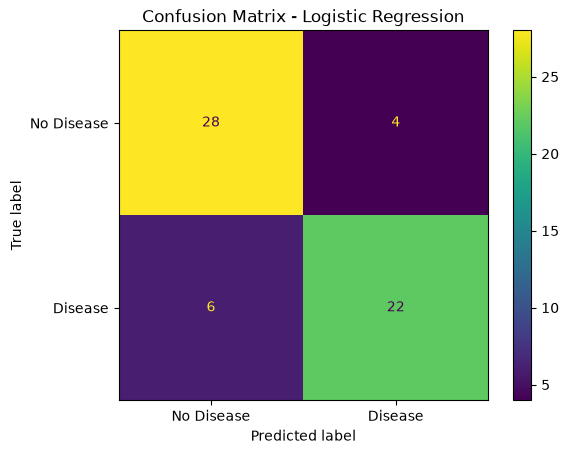

In [36]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

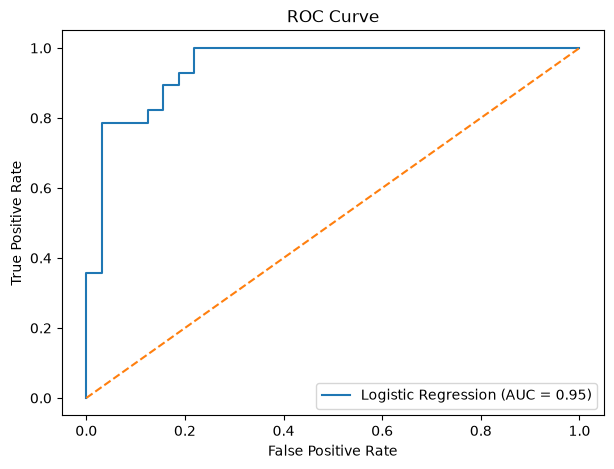

In [37]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

3. Signal data ingestion (ECG)

▪ Use wfdb to fetch a sample MIT-BIH record (e.g., record “100”).

▪ Load the signal and annotation.

▪ Plot a segment of ECG waveform with beat annotations.

▪ Compute basic heart-rate variability or beat interval statistics.

In [38]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print("Record loaded successfully!")

Record loaded successfully!


In [39]:
print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Number of signals:", record.n_sig)
print("Signal names:", record.sig_name)

Signal shape: (650000, 2)
Sampling frequency: 360
Number of signals: 2
Signal names: ['MLII', 'V5']


In [40]:
record.p_signal

array([[-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       ...,
       [-0.675, -0.365],
       [-0.765, -0.335],
       [-1.28 ,  0.   ]], shape=(650000, 2))

In [41]:
annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("Annotations loaded successfully!")
print("Number of annotations:", len(annotation.sample))

Annotations loaded successfully!
Number of annotations: 2274


In [42]:
print("First 20 annotation samples:")
print(annotation.sample[:20])

print("\nFirst 20 annotation symbols:")
print(annotation.symbol[:20])

First 20 annotation samples:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]

First 20 annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


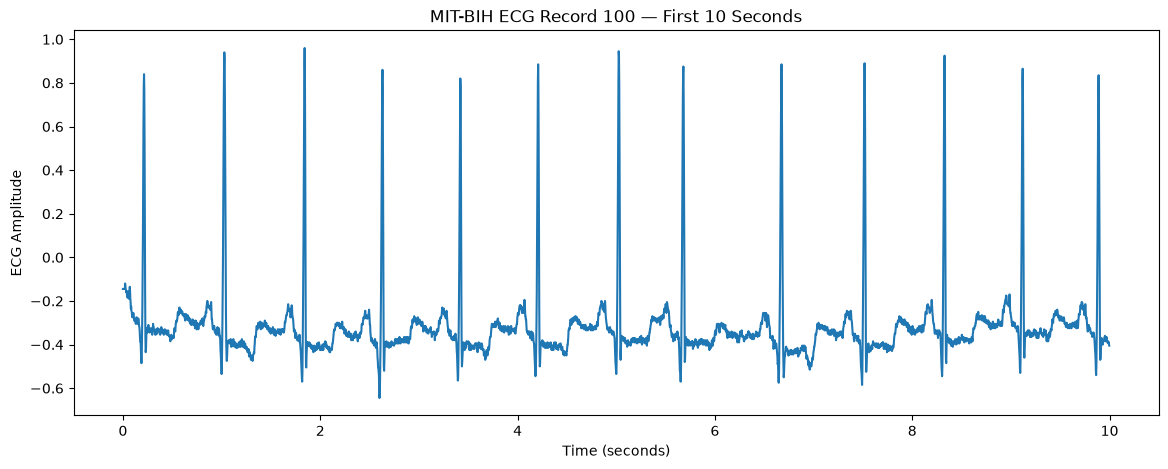

In [43]:
duration = 10  # seconds
samples = int(duration * record.fs)

signal = record.p_signal[:samples, 0]

time = np.arange(len(signal)) / record.fs

plt.figure(figsize=(14, 5))

plt.plot(time, signal)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("MIT-BIH ECG Record 100 — First 10 Seconds")

plt.show()

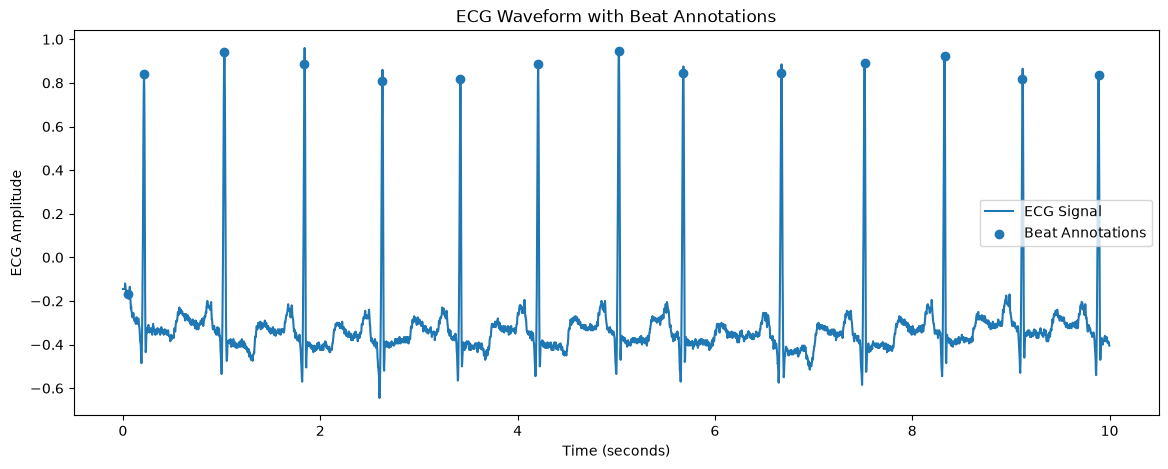

In [44]:
ann_samples = annotation.sample
ann_symbols = annotation.symbol

mask = ann_samples < samples

plt.figure(figsize=(14, 5))

plt.plot(time, signal, label="ECG Signal")

plt.scatter(
    ann_samples[mask] / record.fs,
    record.p_signal[ann_samples[mask], 0],
    marker="o",
    label="Beat Annotations"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("ECG Waveform with Beat Annotations")

plt.legend()
plt.show()

In [45]:
normal_beats = annotation.sample[
    np.array(annotation.symbol) == "N"
]

normal_beats = normal_beats[normal_beats < samples]

print("Number of normal beats:", len(normal_beats))

Number of normal beats: 12


In [46]:
rr_intervals = np.diff(normal_beats) / record.fs

print("RR intervals (seconds):")
print(rr_intervals)

RR intervals (seconds):
[0.81388889 0.81111111 0.78888889 0.79166667 0.78888889 0.81666667
 1.64722222 0.84444444 0.81111111 0.78888889 0.77222222]


In [47]:
print("Mean RR interval:", np.mean(rr_intervals), "seconds")
print("Minimum RR interval:", np.min(rr_intervals), "seconds")
print("Maximum RR interval:", np.max(rr_intervals), "seconds")
print("Standard deviation:", np.std(rr_intervals), "seconds")

Mean RR interval: 0.8795454545454546 seconds
Minimum RR interval: 0.7722222222222223 seconds
Maximum RR interval: 1.6472222222222221 seconds
Standard deviation: 0.24347625273180545 seconds


In [48]:
mean_rr = np.mean(rr_intervals)

heart_rate = 60 / mean_rr

print(f"Estimated Average Heart Rate: {heart_rate:.2f} BPM")

Estimated Average Heart Rate: 68.22 BPM


4. Textual data demonstration

▪ Include a synthetic or small sample clinical note (e.g., a plain text “patient note” describing
chest pain symptoms).

▪ Tokenize, compute word frequency, and extract key terms (simple NLP).

In [49]:
clinical_note = """
The patient is a 55 year old male who reports chest pain and
shortness of breath. The chest pain started two days ago and
increases during physical activity. The patient has a history
of high blood pressure and high cholesterol.
"""

print(clinical_note)


The patient is a 55 year old male who reports chest pain and
shortness of breath. The chest pain started two days ago and
increases during physical activity. The patient has a history
of high blood pressure and high cholesterol.



In [51]:
import re

tokens = re.findall(r'\b\w+\b', clinical_note.lower())

print("Tokens:")
print(tokens)

Tokens:
['the', 'patient', 'is', 'a', '55', 'year', 'old', 'male', 'who', 'reports', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'the', 'chest', 'pain', 'started', 'two', 'days', 'ago', 'and', 'increases', 'during', 'physical', 'activity', 'the', 'patient', 'has', 'a', 'history', 'of', 'high', 'blood', 'pressure', 'and', 'high', 'cholesterol']


In [52]:
print("Total number of tokens:", len(tokens))

Total number of tokens: 40


In [53]:
stop_words = {
    "the", "is", "a", "an", "and", "of", "to",
    "in", "who", "has", "with", "during", "two"
}

filtered_tokens = [
    word for word in tokens
    if word not in stop_words
]

print("Tokens after removing stop words:")
print(filtered_tokens)

Tokens after removing stop words:
['patient', '55', 'year', 'old', 'male', 'reports', 'chest', 'pain', 'shortness', 'breath', 'chest', 'pain', 'started', 'days', 'ago', 'increases', 'physical', 'activity', 'patient', 'history', 'high', 'blood', 'pressure', 'high', 'cholesterol']


In [54]:
from collections import Counter

word_frequency = Counter(filtered_tokens)

print("Word Frequency:")
print(word_frequency)

Word Frequency:
Counter({'patient': 2, 'chest': 2, 'pain': 2, 'high': 2, '55': 1, 'year': 1, 'old': 1, 'male': 1, 'reports': 1, 'shortness': 1, 'breath': 1, 'started': 1, 'days': 1, 'ago': 1, 'increases': 1, 'physical': 1, 'activity': 1, 'history': 1, 'blood': 1, 'pressure': 1, 'cholesterol': 1})


In [55]:
most_common_words = word_frequency.most_common(10)

print("Top 10 most frequent words:")

for word, count in most_common_words:
    print(f"{word}: {count}")

Top 10 most frequent words:
patient: 2
chest: 2
pain: 2
high: 2
55: 1
year: 1
old: 1
male: 1
reports: 1
shortness: 1


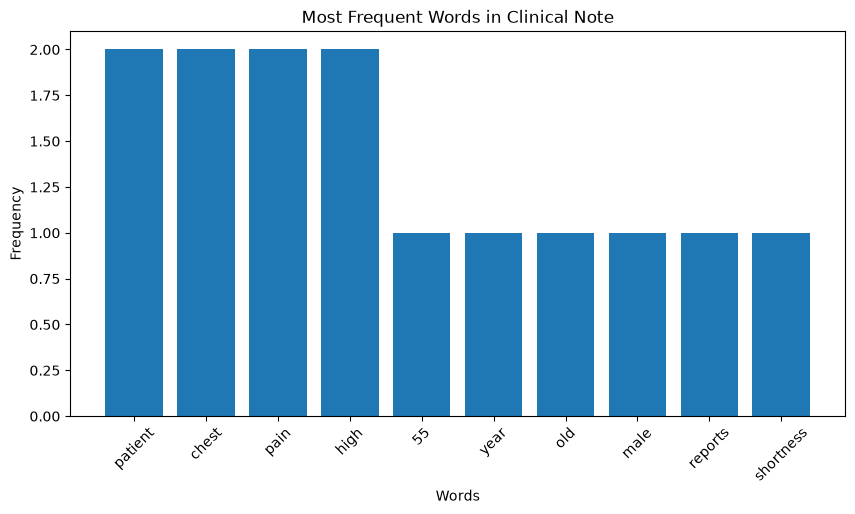

In [56]:
words = [item[0] for item in most_common_words]
counts = [item[1] for item in most_common_words]

plt.figure(figsize=(10, 5))

plt.bar(words, counts)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Most Frequent Words in Clinical Note")

plt.xticks(rotation=45)

plt.show()

In [57]:
medical_terms = {
    "chest",
    "pain",
    "shortness",
    "breath",
    "blood",
    "pressure",
    "cholesterol",
    "activity"
}

key_terms = [
    word for word in filtered_tokens
    if word in medical_terms
]

print("Key medical terms:")
print(sorted(set(key_terms)))

Key medical terms:
['activity', 'blood', 'breath', 'chest', 'cholesterol', 'pain', 'pressure', 'shortness']


In [58]:
key_term_frequency = Counter(key_terms)

print("Key Medical Terms and Their Frequencies:")

for term, count in key_term_frequency.items():
    print(f"{term}: {count}")

Key Medical Terms and Their Frequencies:
chest: 2
pain: 2
shortness: 1
breath: 1
activity: 1
blood: 1
pressure: 1
cholesterol: 1


5. Image data demonstration (optional placeholder)

▪ Use a publicly available medical image (e.g., a sample chest X-ray from a CC0 collection) or
synthetic image.

▪ Load with Pillow, display, and resize.

▪ Extract metadata if possible.

In [64]:
from PIL import Image

image_path = "chest_xray.jpg"

image = Image.open(image_path)

print("Image loaded successfully!")

Image loaded successfully!


In [65]:
# metadata of the image

print("Image format:", image.format)
print("Image size:", image.size)
print("Image mode:", image.mode)

Image format: JPEG
Image size: (442, 442)
Image mode: RGB


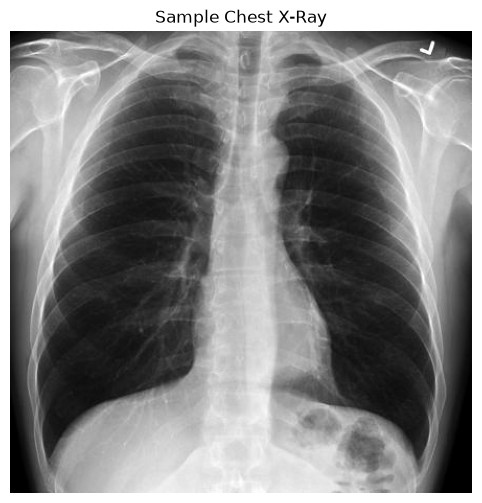

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(image, cmap="gray")

plt.axis("off")
plt.title("Sample Chest X-Ray")

plt.show()

Original size: (442, 442)
Resized size: (224, 224)


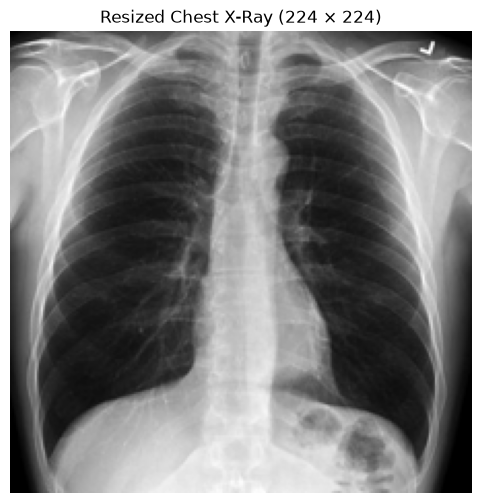

In [67]:
resized_image = image.resize((224, 224))

print("Original size:", image.size)
print("Resized size:", resized_image.size)

plt.figure(figsize=(6, 6))

plt.imshow(resized_image, cmap="gray")

plt.axis("off")
plt.title("Resized Chest X-Ray (224 × 224)")

plt.show()

In [68]:
print("Image metadata:")

if image.info:
    print(image.info)
else:
    print("No additional metadata available.")

Image metadata:
{'jfif': 257, 'jfif_version': (1, 1), 'dpi': (72, 72), 'jfif_unit': 1, 'jfif_density': (72, 72), 'xmp': b'<?xpacket begin="\xef\xbb\xbf" id="W5M0MpCehiHzreSzNTczkc9d"?> <x:xmpmeta xmlns:x="adobe:ns:meta/" x:xmptk="Adobe XMP Core 4.2.2-c063 53.352624, 2008/07/30-18:05:41        "> <rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"> <rdf:Description rdf:about="" xmlns:xmp="http://ns.adobe.com/xap/1.0/" xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:photoshop="http://ns.adobe.com/photoshop/1.0/" xmlns:xmpMM="http://ns.adobe.com/xap/1.0/mm/" xmlns:stEvt="http://ns.adobe.com/xap/1.0/sType/ResourceEvent#" xmlns:tiff="http://ns.adobe.com/tiff/1.0/" xmlns:exif="http://ns.adobe.com/exif/1.0/" xmp:CreatorTool="Adobe Photoshop CS4 Macintosh" xmp:CreateDate="2009-12-02T09:36:32-05:00" xmp:ModifyDate="2010-01-22T14:55:27-05:00" xmp:MetadataDate="2010-01-22T14:55:27-05:00" dc:format="image/jpeg" photoshop:ColorMode="1" photoshop:ICCProfile="Dot Gain 20%" xmpMM:Instan

6. Integration Discussion

▪ Outline (in markdown) how heart disease risk (tabular) could be augmented with ECGderived features, and how text notes could provide context (symptoms) in a future fused
model.

## 6. Integration Discussion

Heart disease prediction can be improved by combining different types
of medical data.

- **Tabular data:** Patient details such as age, blood pressure,
  cholesterol, and other clinical values can be used to estimate
  heart disease risk.

- **ECG data:** ECG signals can provide useful information such as
  heart rate and RR intervals, which can give additional information
  about the patient's heart condition.

- **Text data:** Clinical notes can provide symptoms such as chest pain,
  shortness of breath, and dizziness that may not be present in
  structured data.

In the future, these tabular, ECG, and text features can be combined
to build a single model for better heart disease risk prediction.